<a href="https://colab.research.google.com/github/jane-disciullo/sp500-backtesting-strategy/blob/main/notebooks/05_regime_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Regime Analysis

This notebook evaluates whether the performance of the 200-day moving-average strategy changes across different market regimes.

Rather than evaluating the strategy only over the full sample period, I examined how the strategy behaves under different market conditions. Market regimes are identified using rolling realized volatility, allowing performance to be compared across low and high volatility environments.

The analysis compares the 200-day MA hypothesis with a buy-and-hold SPY benchmark using:

- Total return
- CAGR
- Sharpe ratio
- Maximum drawdown
- Portfolio growth

The goal is to determine whether the moving-average signal provides a consistent advantage across different market environments or whether its performance is regime-dependent.

This notebook was developed with assistance from AI tools for debugging, troubleshooting, and syntax correction.

In [26]:
price = load_spy_data(
    start="2015-01-01",
    end="2026-01-01",
    interval="1d"
)

print(f"Data loaded: {price.shape[0]} rows")
print(f"Date range: {price.index.min()} to {price.index.max()}")

/content/sp500-backtesting-strategy/src/data.py:19: FutureWarning: YF.download() has changed argument auto_adjust default to True
  price = yf.download(
[*********************100%***********************]  1 of 1 completed

Data loaded: 2766 rows
Date range: 2015-01-02 00:00:00 to 2025-12-31 00:00:00


In [27]:
strategy = price.copy()

strategy = generate_ma_signal(strategy, ma=200)
strategy = run_backtest(strategy, starting_balance=100000)

print(strategy.columns.tolist())

['Close', 'High', 'Low', 'Open', 'Volume', 'Daily_Return', 'Return', 'Bench_Bal', 'MA', 'Long', 'Sys_Ret', 'Sys_Bal']


In [28]:
strategy["Volatility_20D"] = (
    strategy["Daily_Return"]
    .rolling(20)
    .std()
    * np.sqrt(252)
)

strategy[["Daily_Return", "Volatility_20D"]].tail()

,Daily_Return,Volatility_20D
Date,,
2025-12-24,0.003518,0.089319
2025-12-26,-0.000101,0.086907
2025-12-29,-0.003564,0.086583
2025-12-30,-0.001221,0.084790
2025-12-31,-0.007409,0.089307


## Volatility Regime Definition

To define the different market regimes, I use the median of the 20-day realized volatility measure. Days with volatility below the median are classified as **Low Volatility**, while days at or above the median are classified as **High Volatility.**

Using the median creates two relatively balanced groups, which makes it easier to compare how the 200-day moving-average strategy performs under different market conditions.

In [29]:
vol_median = strategy["Volatility_20D"].median()

print(f"Median 20-day realized volatility: {vol_median:.2%}")

Median 20-day realized volatility: 12.22%


In [30]:
strategy["Regime"] = np.where(
    strategy["Volatility_20D"] < vol_median,
    "Low Volatility",
    "High Volatility"
)

strategy["Regime"].value_counts()

,count
Regime,
High Volatility,1393
Low Volatility,1373


In [31]:
strategy[["Volatility_20D", "Regime"]].dropna().head(10)

,Volatility_20D,Regime
Date,,
2015-02-02,0.175418,High Volatility
2015-02-03,0.170912,High Volatility
2015-02-04,0.167580,High Volatility
2015-02-05,0.165653,High Volatility
2015-02-06,0.153698,High Volatility
2015-02-09,0.151765,High Volatility
2015-02-10,0.153070,High Volatility
2015-02-11,0.152404,High Volatility
2015-02-12,0.152632,High Volatility


In [32]:
regime_counts = strategy["Regime"].value_counts()

print(regime_counts)
print()
print((regime_counts / regime_counts.sum()).round(3))

Regime
High Volatility    1393
Low Volatility     1373
Name: count, dtype: int64

Regime
High Volatility    0.504
Low Volatility     0.496
Name: count, dtype: float64


## Market Regimes Over Time

The chart below shows how the volatility regime changes throughout the sample period. This helps identify when the market was experiencing relatively low or high realized volatility before comparing strategy performance across the two environments.

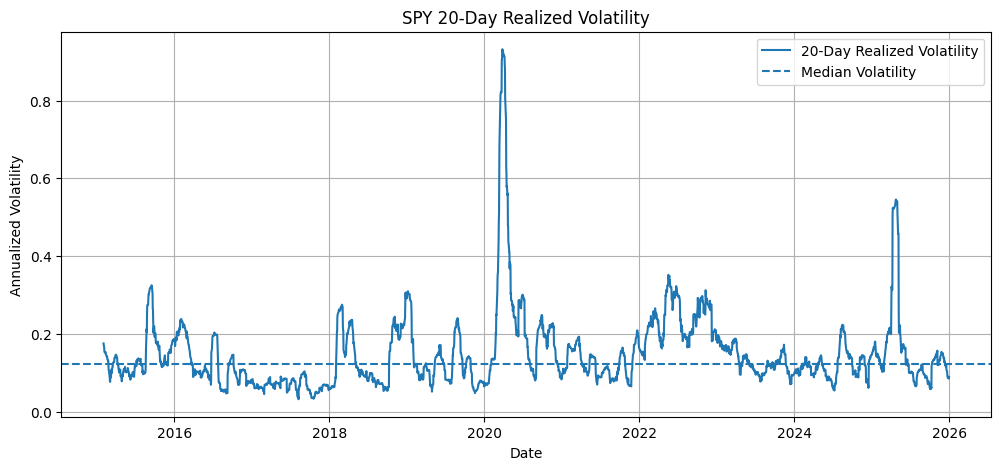

In [33]:
plt.figure(figsize=(12, 5))

plt.plot(
    strategy.index,
    strategy["Volatility_20D"],
    label="20-Day Realized Volatility"
)

plt.axhline(
    vol_median,
    linestyle="--",
    label="Median Volatility"
)

plt.title("SPY 20-Day Realized Volatility")
plt.xlabel("Date")
plt.ylabel("Annualized Volatility")
plt.legend()
plt.grid(True)

plt.show()

## Performance by Volatility Regime

Next, I compare the 200-day moving-average strategy with buy-and-hold separately within each volatility regime.

This helps determine whether the strategy's performance is consistent across different market environments or whether its results are mainly driven by a particular volatility regime.

In [34]:
regime_returns = strategy[[
    "Regime",
    "Daily_Return",
    "Sys_Ret"
]].dropna().copy()

# Sys_Ret is a growth factor, so convert it to an actual return
regime_returns["Strategy_Return"] = regime_returns["Sys_Ret"] - 1

# Remove the original growth-factor column
regime_returns = regime_returns.drop(columns="Sys_Ret")

regime_return_summary = (
    regime_returns
    .groupby("Regime")[["Daily_Return", "Strategy_Return"]]
    .mean()
)

regime_return_summary.columns = [
    "Buy & Hold",
    "200-Day MA"
]

# Display as percentages
regime_return_summary_display = (
    regime_return_summary * 100
).round(4)

regime_return_summary_display

,Buy & Hold,200-Day MA
Regime,,
High Volatility,0.0455,0.0148
Low Volatility,0.0675,0.0674


## Risk-Adjusted Performance by Regime


In [35]:
def regime_risk_metrics(data, regime, return_column, balance_column):
    subset = data[data["Regime"] == regime].copy()

    returns = subset[return_column].dropna()

    sharpe = (
        returns.mean() / returns.std()
    ) * np.sqrt(252)

    balance = subset[balance_column].dropna()

    drawdown = balance / balance.cummax() - 1
    max_drawdown = drawdown.min()

    return sharpe, max_drawdown

In [36]:
strategy["Strategy_Return"] = strategy["Sys_Ret"] - 1

In [37]:
regimes = ["Low Volatility", "High Volatility"]

regime_risk = []

for regime in regimes:

    bh_sharpe, bh_dd = regime_risk_metrics(
        strategy,
        regime,
        "Daily_Return",
        "Bench_Bal"
    )

    ma_sharpe, ma_dd = regime_risk_metrics(
        strategy,
        regime,
        "Strategy_Return",
        "Sys_Bal"
    )

    regime_risk.append({
        "Regime": regime,
        "Buy & Hold Sharpe": bh_sharpe,
        "200-Day MA Sharpe": ma_sharpe,
        "Buy & Hold Max Drawdown": bh_dd,
        "200-Day MA Max Drawdown": ma_dd
    })

regime_risk_df = pd.DataFrame(regime_risk)

regime_risk_df

,Regime,Buy & Hold Sharpe,200-Day MA Sharpe,Buy & Hold Max Drawdown,200-Day MA Max Drawdown
0,Low Volatility,1.839375,1.926750,-0.118776,-0.151423
1,High Volatility,0.491444,0.276848,-0.337173,-0.198069


## Portfolio Growth by Volatility Regime

In [38]:
import matplotlib.pyplot as plt

low_vol = strategy[strategy["Regime"] == "Low Volatility"].copy()
high_vol = strategy[strategy["Regime"] == "High Volatility"].copy()

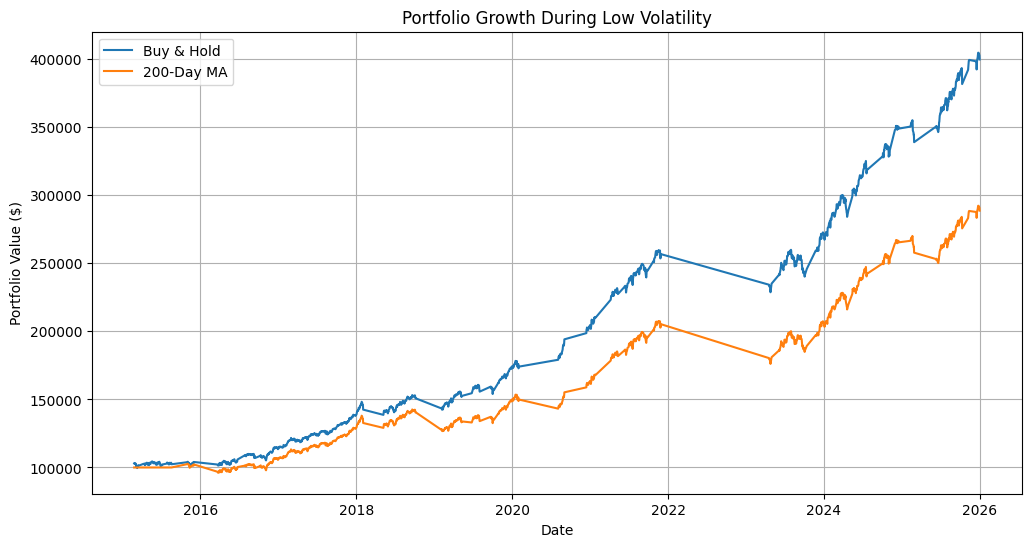

In [40]:
plt.figure(figsize=(12, 6))

plt.plot(
    low_vol.index,
    low_vol["Bench_Bal"],
    label="Buy & Hold"
)

plt.plot(
    low_vol.index,
    low_vol["Sys_Bal"],
    label="200-Day MA"
)

plt.title("Portfolio Growth During Low Volatility")
plt.xlabel("Date")
plt.ylabel("Portfolio Value ($)")
plt.legend()
plt.grid(True)

plt.show()

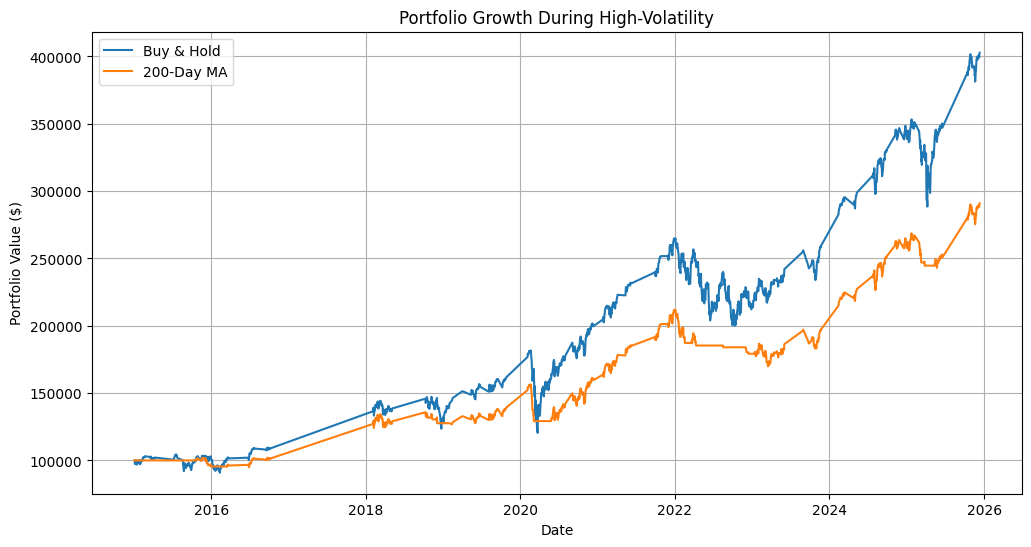

In [41]:
plt.figure(figsize=(12, 6))

plt.plot(
    high_vol.index,
    high_vol["Bench_Bal"],
    label="Buy & Hold"
)

plt.plot(
    high_vol.index,
    high_vol["Sys_Bal"],
    label="200-Day MA"
)

plt.title("Portfolio Growth During High-Volatility")
plt.xlabel("Date")
plt.ylabel("Portfolio Value ($)")
plt.legend()
plt.grid(True)

plt.show()

## Final Regime Analysis Summary

The regime analysis shows that the 200-day MA strategy does not outperform buy-and-hold across all market environments.

During low-volatility periods, the MA strategy has a slightly higher Sharpe ratio, but it also experiences a larger maximum drawdown. During high-volatility periods, buy-and-hold produces a higher Sharpe ratio, while the MA strategy significantly reduces maximum drawdown.

The results suggest that the main potential benefit of the 200-day MA is downside-risk reduction during periods of elevated volatility rather than higher returns. The strategy still underperforms buy-and-hold over the full sample and therefore does not provide evidence of a consistent return advantage.

This result is useful because it shows that the effectiveness of the signal depends on the market environment rather than being constant across the sample.

In [42]:
final_regime_summary = regime_risk_df.copy()

final_regime_summary["Buy & Hold Sharpe"] = (
    final_regime_summary["Buy & Hold Sharpe"].round(2)
)

final_regime_summary["200-Day MA Sharpe"] = (
    final_regime_summary["200-Day MA Sharpe"].round(2)
)

final_regime_summary["Buy & Hold Max Drawdown"] = (
    final_regime_summary["Buy & Hold Max Drawdown"] * 100
).round(2).astype(str) + "%"

final_regime_summary["200-Day MA Max Drawdown"] = (
    final_regime_summary["200-Day MA Max Drawdown"] * 100
).round(2).astype(str) + "%"

final_regime_summary

,Regime,Buy & Hold Sharpe,200-Day MA Sharpe,Buy & Hold Max Drawdown,200-Day MA Max Drawdown
0,Low Volatility,1.84,1.93,-11.88%,-15.14%
1,High Volatility,0.49,0.28,-33.72%,-19.81%
